# 06 - Estrategia: Multi-Factor con Scoring y Ranking

**Capítulo**: 06 - Multi-Factor

**Objetivo**: Implementar sistema de scoring multi-factor, ranking de activos y selección de portfolio.

---

In [1]:
import sys
sys.path.insert(0, '../..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from curso.lib.data import download_multiple
from curso.lib.indicators import sma, rsi, atr, momentum

plt.style.use('seaborn-v0_8-whitegrid')
print('Setup completado ✓')

Setup completado ✓


## 1. Universo de activos

In [2]:
# Universo diversificado por sector (20 activos)
UNIVERSE = [
    'AAPL', 'MSFT', 'GOOGL', 'AMZN',  # Tech
    'JNJ', 'PFE', 'UNH', 'ABBV',      # Healthcare
    'JPM', 'BAC', 'GS', 'V',           # Financials
    'XOM', 'CVX', 'COP',               # Energy
    'PG', 'KO', 'WMT',                 # Consumer
    'CAT', 'HON'                        # Industrials
]

datos = download_multiple(UNIVERSE)
print(f'Activos descargados: {len(datos)}/{len(UNIVERSE)}')

Activos descargados: 20/20


## 2. Cálculo de factores

In [3]:
# Parámetros
RSI_PERIOD = 14
ROC_PERIOD = 20
SMA_TREND = 200
ATR_PERIOD = 14

# Pesos
W_MOMENTUM = 0.4
W_TREND = 0.4
W_VOLATILITY = 0.2


def calculate_factors(df):
    """Calcula los 3 factores para un activo."""
    result = {}
    
    # Factor 1: Momentum (RSI + Rate of Change)
    rsi_val = rsi(df, length=RSI_PERIOD).iloc[-1] if len(df) > RSI_PERIOD else 50
    roc_val = ((df['Close'].iloc[-1] / df['Close'].iloc[-ROC_PERIOD]) - 1) * 100 if len(df) > ROC_PERIOD else 0
    result['momentum_rsi'] = rsi_val
    result['momentum_roc'] = roc_val
    
    # Factor 2: Tendencia (distancia a SMA200)
    sma_200 = sma(df, length=SMA_TREND).iloc[-1] if len(df) > SMA_TREND else df['Close'].iloc[-1]
    result['trend_distance'] = ((df['Close'].iloc[-1] / sma_200) - 1) * 100
    
    # Factor 3: Volatilidad (inversa de ATR normalizado)
    atr_val = atr(df, length=ATR_PERIOD).iloc[-1] if len(df) > ATR_PERIOD else 0
    result['volatility_atr'] = atr_val / df['Close'].iloc[-1] * 100  # ATR como % del precio
    
    return result


# Calcular factores para todo el universo
factors_data = []
for ticker, df in datos.items():
    factors = calculate_factors(df)
    factors['ticker'] = ticker
    factors_data.append(factors)

factors_df = pd.DataFrame(factors_data).set_index('ticker')
print(factors_df.round(2))

        momentum_rsi  momentum_roc  trend_distance  volatility_atr
ticker                                                            
AAPL           79.79         15.17           18.90            1.78
MSFT           59.32          4.71           -6.94            2.54
GOOGL          54.59         -0.84           27.51            2.45
AMZN           60.06          0.99           17.02            2.42
JNJ            51.54          0.41            9.07            1.72
PFE            48.89         -2.10            1.21            1.86
UNH            59.73          3.25           17.34            2.42
ABBV           63.48          3.46           -0.39            2.37
JPM            42.25         -5.13           -3.05            1.99
BAC            49.36         -3.59           -0.99            2.06
GS             69.95         10.09           19.07            2.48
V              58.19          0.73           -0.11            1.88
XOM            39.62         -4.34           10.75            

## 3. Normalización y scoring

In [4]:
def normalize(series):
    """Normaliza a [0, 100]."""
    min_val, max_val = series.min(), series.max()
    if max_val == min_val:
        return pd.Series(50, index=series.index)
    return ((series - min_val) / (max_val - min_val)) * 100


# Normalizar cada factor
factors_df['score_momentum'] = (normalize(factors_df['momentum_rsi']) + normalize(factors_df['momentum_roc'])) / 2
factors_df['score_trend'] = normalize(factors_df['trend_distance'])
factors_df['score_volatility'] = 100 - normalize(factors_df['volatility_atr'])  # Invertido: menor vol = mejor

# Score compuesto
factors_df['score_total'] = (
    W_MOMENTUM * factors_df['score_momentum'] +
    W_TREND * factors_df['score_trend'] +
    W_VOLATILITY * factors_df['score_volatility']
)

# Ranking
factors_df['rank'] = factors_df['score_total'].rank(ascending=False).astype(int)
print(factors_df[['score_momentum', 'score_trend', 'score_volatility', 'score_total', 'rank']].sort_values('rank').round(1))

        score_momentum  score_trend  score_volatility  score_total  rank
ticker                                                                  
AAPL             100.0         57.1              85.8         80.0     1
GS                81.2         57.5              40.0         63.5     2
HON               81.2         39.5              59.2         60.1     3
CAT               44.1        100.0               0.0         57.7     4
GOOGL             46.3         76.2              41.9         57.4     5
UNH               58.8         53.7              44.0         53.8     6
KO                48.2         36.2             100.0         53.8     7
AMZN              55.0         53.0              43.4         51.9     8
JNJ               45.6         35.4              89.7         50.3     9
V                 52.7         15.1              79.5         43.0    10
ABBV              62.8         14.5              47.0         40.3    11
PFE               38.5         18.0              80

## 4. Selección Top-K

In [5]:
TOP_K = 5

selected = factors_df.nsmallest(TOP_K, 'rank')
print(f'\n=== TOP {TOP_K} SELECCIONADOS ===')
for i, (ticker, row) in enumerate(selected.iterrows(), 1):
    print(f'  {i}. {ticker}: Score={row["score_total"]:.1f} | Momentum={row["score_momentum"]:.0f} | Trend={row["score_trend"]:.0f} | Vol={row["score_volatility"]:.0f}')

print(f'\nAsignación: {100/TOP_K:.0f}% por posición (Equal Weight)')


=== TOP 5 SELECCIONADOS ===
  1. AAPL: Score=80.0 | Momentum=100 | Trend=57 | Vol=86
  2. GS: Score=63.5 | Momentum=81 | Trend=57 | Vol=40
  3. HON: Score=60.1 | Momentum=81 | Trend=40 | Vol=59
  4. CAT: Score=57.7 | Momentum=44 | Trend=100 | Vol=0
  5. GOOGL: Score=57.4 | Momentum=46 | Trend=76 | Vol=42

Asignación: 20% por posición (Equal Weight)


## 5. Visualización de scores

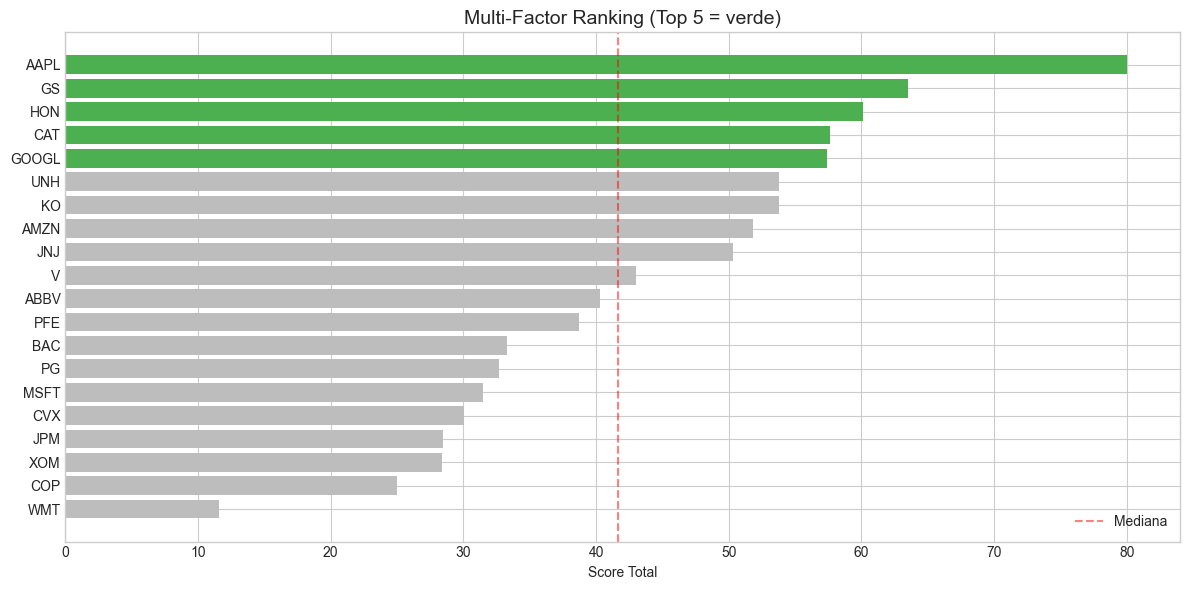

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
sorted_df = factors_df.sort_values('score_total', ascending=True)
colors = ['#4CAF50' if t in selected.index else '#BDBDBD' for t in sorted_df.index]
ax.barh(sorted_df.index, sorted_df['score_total'], color=colors)
ax.axvline(sorted_df['score_total'].median(), color='red', linestyle='--', alpha=0.5, label='Mediana')
ax.set_xlabel('Score Total')
ax.set_title(f'Multi-Factor Ranking (Top {TOP_K} = verde)', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

## Resumen

✅ Descargado universo de 20 activos
✅ Calculados 3 factores (momentum, tendencia, volatilidad)
✅ Normalización y score compuesto
✅ Ranking y selección Top-5
✅ Visualización del ranking

**Siguiente**: `06_backtesting.ipynb`